## Demos of collocation and weighted residual methods

Collocation with different numbers of basis functions

In [5]:
using LinearAlgebra
using Plots

function collocation(N::Integer)
    x = range(-1.0, 1.0; length=201) |> collect
    T = @. -50 * exp(x) + 50 * x * sinh(1.0) + 100 + 50 * cosh(1.0)

    # Each row i stores basis function i evaluated on x
    phi   = Matrix{Float64}(undef, N, length(x))
    phix  = Matrix{Float64}(undef, N, length(x))
    phixx = Matrix{Float64}(undef, N, length(x))

    phi[1, :]   = @. 1 - x^2
    phix[1, :]  = @. -2x
    phixx[1, :] .= -2.0

    for i in 2:N
        @views phi[i, :]   = x .* phi[i-1, :]
        @views phix[i, :]  = phi[i-1, :]  .+ x .* phix[i-1, :]
        @views phixx[i, :] = 2 .* phix[i-1, :] .+ x .* phixx[i-1, :]
    end

    dx_col = 2.0 / (N + 1)
    xcol = collect(-1.0 + dx_col : dx_col : 1.0 - dx_col)

    # Match MATLAB's sampled-grid collocation indices
    Di = ceil(Int, 200 / (N + 1))
    xci = collect(Di:Di:(201 - Di))

    K = phixx[:, xci]'
    b = @. -50 * exp(x[xci])

    a = K \ b

    sol = fill(100.0, length(x))
    R   = @. 50 * exp(x)

    for i in 1:N
        @views sol .+= a[i] .* phi[i, :]
        @views R   .+= a[i] .* phixx[i, :]
    end

    p1 = plot(
        x, sol;
        linestyle = :dash,
        linewidth = 2,
        label = "collocation",
        xlabel = "x",
        ylabel = "u(x)",
        grid = true,
    )
    scatter!(p1, xcol, fill(100.0, length(xcol)); marker = :circle, label = "points")
    plot!(p1, x, T; linewidth = 2, label = "exact")

    p2 = plot(
        x, R;
        linestyle = :dash,
        linewidth = 2,
        label = "residual",
        xlabel = "x",
        ylabel = "R(x)",
        grid = true,
    )
    scatter!(p2, xcol, zeros(length(xcol)); marker = :circle, label = "points")

    return (; x, xcol, a, sol, R, T, p1, p2)
end

collocation (generic function with 1 method)

In [22]:
out = collocation(2);

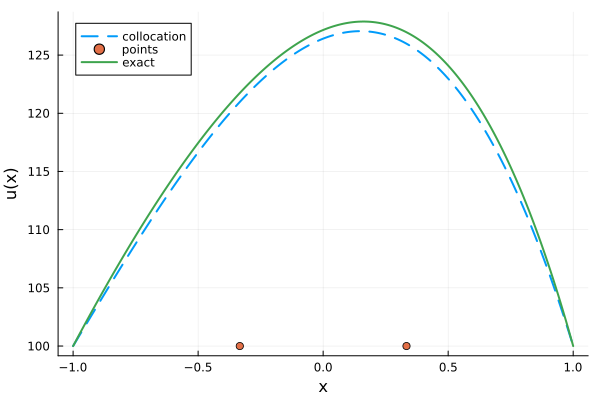

In [23]:
out.p1

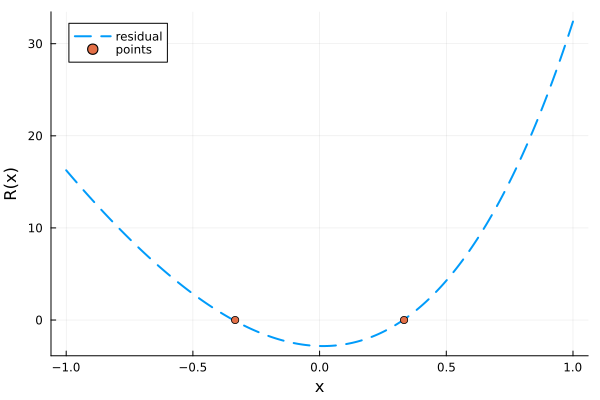

In [24]:
out.p2

OK, now compare collocation with MWR but using only two basis functions (quadratic and cubic).

In [25]:
using LinearAlgebra
using Plots

# method = :collocation  or  :mwr
function mwr_demo(method::Symbol = :collocation)
    # Grid
    x = collect(range(-1.0, 1.0; length=201))

    # Exact/reference solution
    T = @. -50 * exp(x) + 50 * x * sinh(1.0) + 100 + 50 * cosh(1.0)

    # Trial functions
    phi1 = @. (1 - x) * (1 + x)      # = 1 - x^2
    phi2 = @. x * phi1

    # Choose linear system
    if method == :collocation
        K = [-2.0  2.0;
             -2.0 -2.0]
        b = [-50 * exp(-1/3);
             -50 * exp( 1/3)]
    elseif method == :mwr
        K = [-8/3  0.0;
              0.0 -8/5]
        b = [-200 * exp(-1);
             -100 * exp(1) + 700 * exp(-1)]
    else
        error("method must be :collocation or :mwr")
    end

    # Solve for coefficients
    a = K \ b

    # Approximate solution, error, residual
    Ta = @. 100 + a[1] * phi1 + a[2] * phi2
    E  = Ta - T
    R  = @. -2 * a[1] - 6 * a[2] * x + 50 * exp(x)

    # Plots
    p1 = plot(
        x, Ta;
        linestyle = :dash,
        linewidth = 2,
        label = "Approximation",
        xlabel = "x",
        ylabel = "T",
        grid = true,
        title = string("Method: ", method)
    )
    plot!(p1, x, T; linewidth = 2, label = "Exact")

    p2 = plot(
        x, E;
        linewidth = 2,
        label = "Error",
        xlabel = "x",
        ylabel = "Error in T",
        grid = true
    )

    p3 = plot(
        x, R;
        linewidth = 2,
        label = "Residual",
        xlabel = "x",
        ylabel = "Residual",
        grid = true
    )

    return (; x, T, phi1, phi2, K, b, a, Ta, E, R, p1, p2, p3)
end

mwr_demo (generic function with 2 methods)

In [27]:
out = mwr_demo(:mwr);

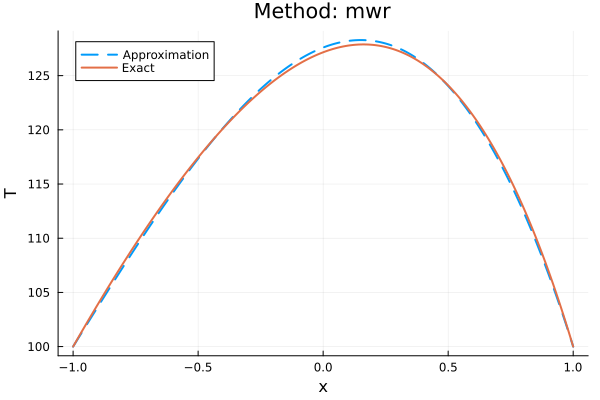

In [28]:
out.p1

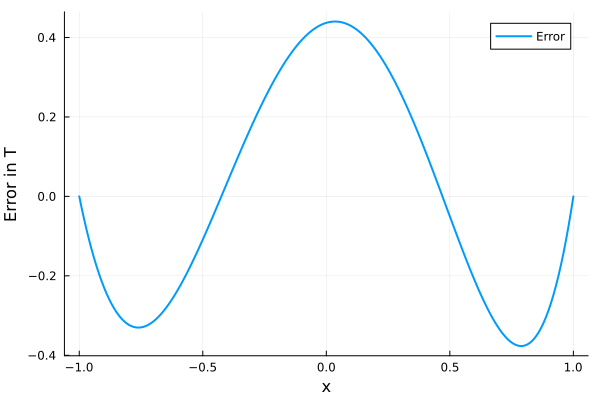

In [29]:
out.p2

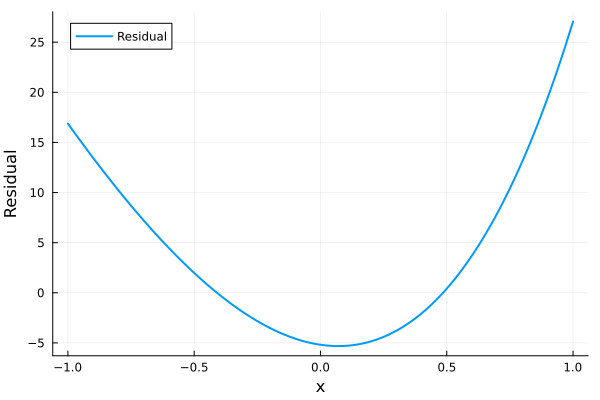

In [30]:
out.p3